In [98]:
import pandas
import numpy
pandas.set_option("display.max_rows", None) 
pandas.set_option("display.max_columns", None)

#Loading the csv dataset "major-tech-stock-2019-2024.csv"
dataset = pandas.read_csv("./datasets/major-tech-stock-2019-2024.csv", header=0, index_col=0)

#Inspecting this dataset
print(dataset.head(), "\n")
print(dataset.tail(), "\n")
print(dataset.info(), "\n")
print(dataset.describe(), "\n")

                 Open       High        Low      Close  Adj Close     Volume  \
Date                                                                           
2019-01-02  38.722500  39.712502  38.557499  39.480000  37.793785  148158800   
2019-01-03  35.994999  36.430000  35.500000  35.547501  34.029243  365248800   
2019-01-04  36.132500  37.137501  35.950001  37.064999  35.481926  234428400   
2019-01-07  37.174999  37.207500  36.474998  36.982498  35.402950  219111200   
2019-01-08  37.389999  37.955002  37.130001  37.687500  36.077847  164101200   

           Ticker  
Date               
2019-01-02   AAPL  
2019-01-03   AAPL  
2019-01-04   AAPL  
2019-01-07   AAPL  
2019-01-08   AAPL   

                  Open        High         Low       Close   Adj Close  \
Date                                                                     
2023-12-22  256.760010  258.220001  251.369995  252.539993  252.539993   
2023-12-26  254.490005  257.970001  252.910004  256.609985  256.609985   
2

In [99]:
from sklearn.preprocessing import OrdinalEncoder

#Data Preprocessing: Ticker has even distribution across the 5 companies, so no sampling resolution is needed here.
print(dataset["Ticker"].value_counts(), "\n")

#Data Preprocessing: Ticker is a string column. It need to be encoded into numeric data using OrdinalEncoder
ordEnc = OrdinalEncoder(categories="auto")
dataset["Ticker"] = ordEnc.fit_transform(dataset[ ["Ticker"] ])

print(dataset["Ticker"].value_counts())

Ticker
AAPL     1258
MSFT     1258
AMZN     1258
GOOGL    1258
TSLA     1258
Name: count, dtype: int64 

Ticker
0.0    1258
3.0    1258
1.0    1258
2.0    1258
4.0    1258
Name: count, dtype: int64


In [100]:
#Since this dataset has 5 different tickers (AAPL, MSFT, AMZN, GOOGL, TSLA), we need to group the generated features per ticker

#Feature Generation: MA_7 (7 Day Moving Average)
dataset["MA_7"] = (dataset.groupby("Ticker")["Adj Close"].transform(lambda x: x.rolling(window=7).mean()))

#Feature Generation: MA_30 (30 day moving average)
dataset["MA_30"] = (dataset.groupby("Ticker")["Adj Close"].transform(lambda x: x.rolling(window=30).mean()))

#Feature Generation: Daily_Return (% return from open to close)
dataset["Daily_Return"] = (dataset["Close"] - dataset["Open"]) / dataset["Open"]

#Feature Generation: Momentum (how fast the price changes over 7 days)
dataset["Momentum_7d"] = (dataset.groupby("Ticker")["Adj Close"].transform(lambda x: x.pct_change(periods=7) * 100))

#Feature Generation: Volatility_7d (how much does the price fluctuate)
dataset["Volatility_7d"] = (dataset.groupby("Ticker")["Adj Close"].transform(lambda x: x.pct_change().rolling(7).std() * (252 ** 0.5)))        

def rsi(series, period=14):                                                             
    delta = series.diff()                                                               
    gain = delta.clip(lower=0).rolling(period).mean()                                   
    loss = -delta.clip(upper=0).rolling(period).mean()                                  
    return 100 - (100 / (1 + gain / loss))                                              

#Feature Generation: RSI_14 (range (0-100): >70 = overbought, <30 = oversold)                                                                     
dataset["RSI_14"] = (dataset.groupby("Ticker")["Adj Close"].transform(rsi))

#Viewing our newly generated features
print(dataset.info(), "\n")

<class 'pandas.DataFrame'>
Index: 6290 entries, 2019-01-02 to 2023-12-29
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Open           6290 non-null   float64
 1   High           6290 non-null   float64
 2   Low            6290 non-null   float64
 3   Close          6290 non-null   float64
 4   Adj Close      6290 non-null   float64
 5   Volume         6290 non-null   int64  
 6   Ticker         6290 non-null   float64
 7   MA_7           6260 non-null   float64
 8   MA_30          6145 non-null   float64
 9   Daily_Return   6290 non-null   float64
 10  Momentum_7d    6255 non-null   float64
 11  Volatility_7d  6255 non-null   float64
 12  RSI_14         6220 non-null   float64
dtypes: float64(12), int64(1)
memory usage: 817.0+ KB
None 



In [101]:
#Data Preprocessing: Rolling/window-absed features (MA_7, MA_30, Momentum_7d, Volatility_7d, RSI_14) produce NaN
#for the first (window_size - 1) rows per ticker. These rows will be dropped

#I'm not imputing NaNs here because they will be misleading values. At most we are losing 29 rows per ticker

dataset.dropna(inplace=True)
print(dataset.info(), "\n")

<class 'pandas.DataFrame'>
Index: 6145 entries, 2019-02-13 to 2023-12-29
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Open           6145 non-null   float64
 1   High           6145 non-null   float64
 2   Low            6145 non-null   float64
 3   Close          6145 non-null   float64
 4   Adj Close      6145 non-null   float64
 5   Volume         6145 non-null   int64  
 6   Ticker         6145 non-null   float64
 7   MA_7           6145 non-null   float64
 8   MA_30          6145 non-null   float64
 9   Daily_Return   6145 non-null   float64
 10  Momentum_7d    6145 non-null   float64
 11  Volatility_7d  6145 non-null   float64
 12  RSI_14         6145 non-null   float64
dtypes: float64(12), int64(1)
memory usage: 672.1+ KB
None 



In [102]:
#Feature Selection: choosing "Adj Close" as the regression target feature instead of "Close" because it 
#corrects artificial price jumps on split dates

#The "Adj Close" feature gets shifted one day back, because this is a forecasting task. 
#We want day n to predict day n + 1's adj close.
dataset["Target"] = (                                                                                                               
    dataset.groupby("Ticker")["Adj Close"]
    .transform(lambda x: x.shift(-1))  # next day's price
)

#Classification target: 1 = price goes up, 0 = price goes down
dataset["Direction"] = (dataset["Target"] > dataset["Adj Close"]).astype(int)

dataset.dropna(inplace=True)  # drops last row per ticker (no next day)
                                                                                                                                      
trgt_y = dataset[["Target", "Direction"]]
feats_X = dataset.drop(columns=["Target", "Direction", "Adj Close", "Close"])  

print(trgt_y.shape, "\n")
print(feats_X.shape, "\n")
print(trgt_y["Direction"].value_counts()) 
# Direction is a roughly equal classification target, no oversampling needed

(6140, 2) 

(6140, 11) 

Direction
1    3272
0    2868
Name: count, dtype: int64


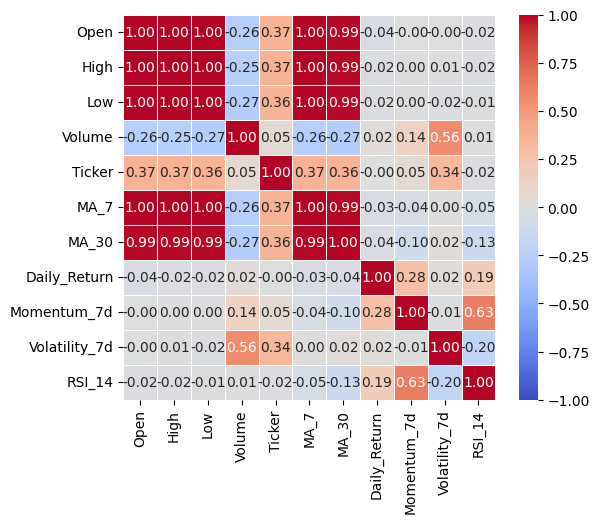

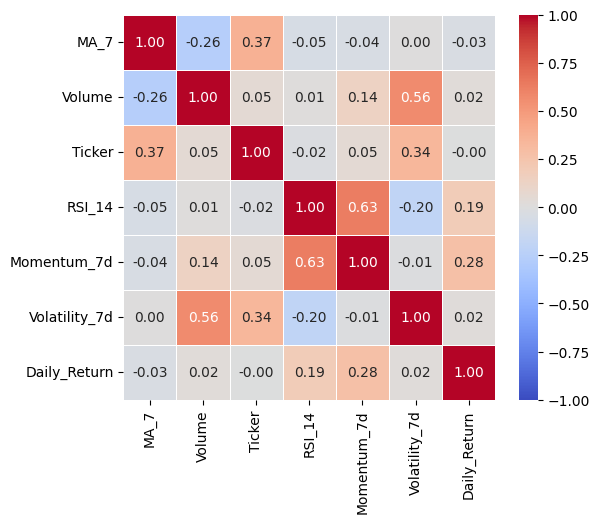

In [103]:
import seaborn as sbn
import matplotlib.pyplot as plt

#Feature Selection: Removing features that are highly correlated to each other
feats_corr = feats_X.corr('pearson')  # Linear(pearson) to target; Nonlinear(kendall|spearman) to target  
plt.figure(figsize=(6, 5))
sbn.heatmap(
    feats_corr, 
    annot=True, 
    linewidths=0.5, 
    fmt='.2f', 
    cmap='coolwarm', 
    center=0, 
    vmin=-1, 
    vmax=1
)
plt.show()

#Open, High, Low, MA_7, MA_30 are all highly correlated. Keeping MA_7 from these because it gives a smoothed price signal

useful_feats_X = feats_X[ ["MA_7", "Volume", "Ticker", "RSI_14", "Momentum_7d", "Volatility_7d", "Daily_Return"] ]
useful_feats_corr = useful_feats_X.corr('pearson')  # Linear(pearson) to target; Nonlinear(kendall|spearman) to target  
plt.figure(figsize=(6, 5))
sbn.heatmap(
    useful_feats_corr, 
    annot=True, 
    linewidths=0.5, 
    fmt='.2f', 
    cmap='coolwarm', 
    center=0, 
    vmin=-1, 
    vmax=1
)
plt.show()

#Feature Correlation matrix looks good now. These will be used to train



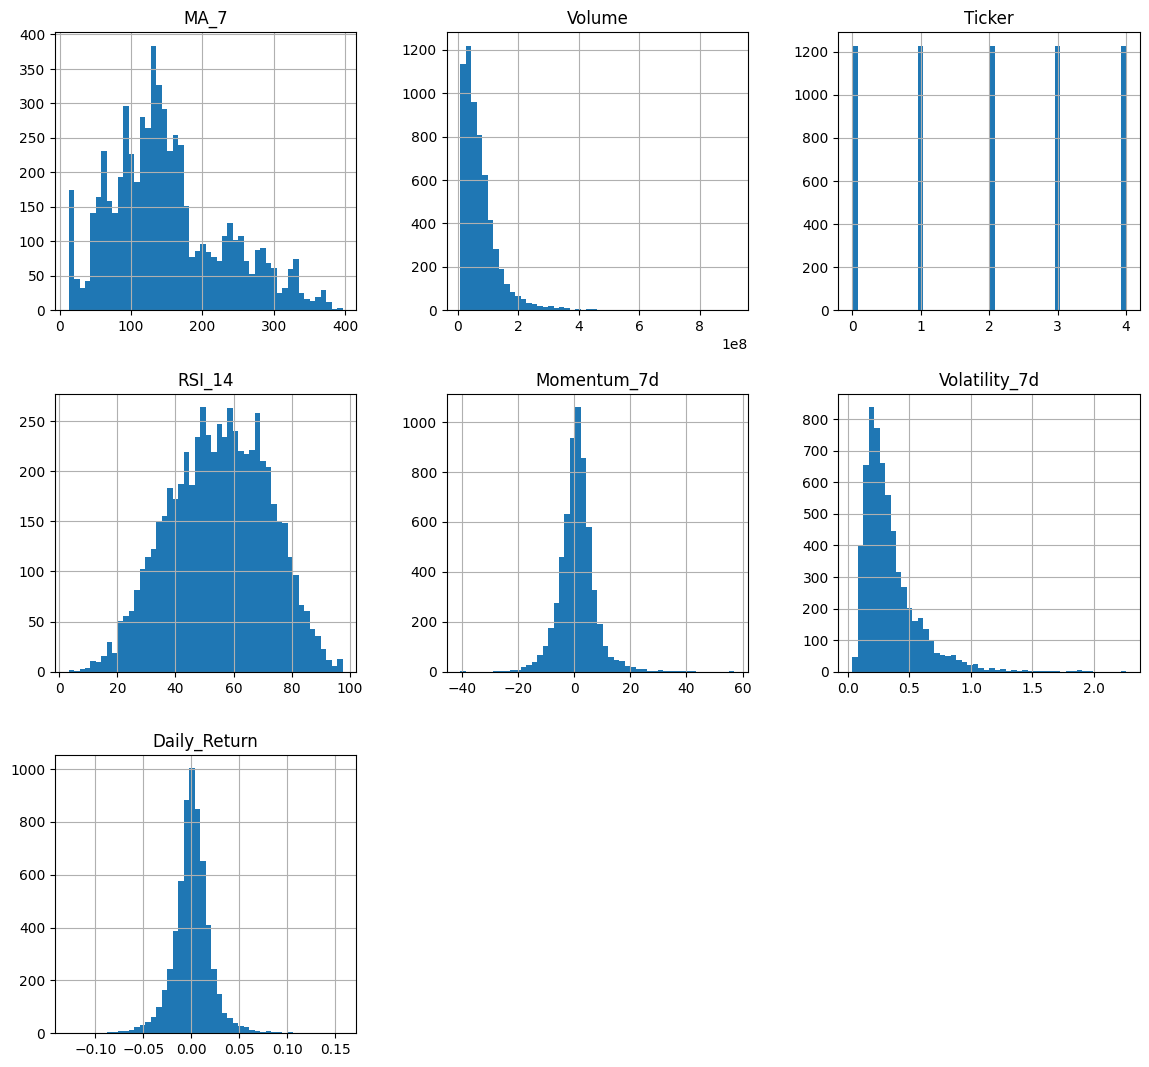

In [104]:
useful_feats_X.hist(bins=50, figsize=(14, 13))
plt.show()



In [105]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Combine features and targets
data = useful_feats_X.join(trgt_y)

# Lists to store split data
train_list = []
test_list = []

# Perform chronological split per ticker
for ticker in data["Ticker"].unique():
    ticker_df = data[data["Ticker"] == ticker].sort_index()

    # 80/20 split
    split_idx = int(len(ticker_df) * 0.8)

    train_list.append(ticker_df.iloc[:split_idx])
    test_list.append(ticker_df.iloc[split_idx:])

# Concatenate all ticker splits
train_df = pd.concat(train_list)
test_df = pd.concat(test_list)

# Select feature columns
feature_cols = useful_feats_X.columns

# Split into training and testing features
X_train = train_df[feature_cols]
X_test = test_df[feature_cols]

# Initialize scaler and standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Extract regression targets
y_train_reg = train_df["Target"]
y_test_reg = test_df["Target"]

# Extract classification targets
y_train_clf = train_df["Direction"]
y_test_clf = test_df["Direction"]

# Train classification model
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train_clf)
y_pred_clf = clf.predict(X_test)

# Train regression model
reg = RandomForestRegressor(n_estimators=100, random_state=42)
reg.fit(X_train, y_train_reg)
y_pred_reg = reg.predict(X_test)

# Evaluate classification performance
print("Accuracy:", accuracy_score(y_test_clf, y_pred_clf))
print(classification_report(y_test_clf, y_pred_clf))

# Evaluate regression performance
print("MAE:", mean_absolute_error(y_test_reg, y_pred_reg))
print("RMSE:", np.sqrt(mean_squared_error(y_test_reg, y_pred_reg)))
print("R2:", r2_score(y_test_reg, y_pred_reg))

Accuracy: 0.49022801302931596
              precision    recall  f1-score   support

           0       0.43      0.43      0.43      2760
           1       0.54      0.54      0.54      3380

    accuracy                           0.49      6140
   macro avg       0.48      0.48      0.48      6140
weighted avg       0.49      0.49      0.49      6140

MAE: 65.94627777849226
RMSE: 79.70830660817545
R2: -0.05809582526555701


In [106]:
# Verify dataset split and class distribution to ensure no imbalance or data issues
print("Train size:", len(X_train))
print("Test size:", len(X_test))

print("\nDirection distribution (test):")
print(y_test_clf.value_counts())

Train size: 24560
Test size: 6140

Direction distribution (test):
Direction
1    3380
0    2760
Name: count, dtype: int64


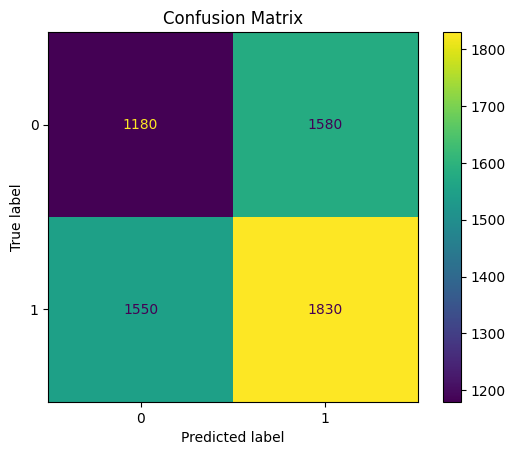

In [107]:
# Import tools for evaluating classification performance and visualization
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Compute confusion matrix comparing true vs predicted labels
cm = confusion_matrix(y_test_clf, y_pred_clf)

# Create display object for visualization
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

# Plot confusion matrix
disp.plot()
plt.title("Confusion Matrix")

# Show plot
plt.show()

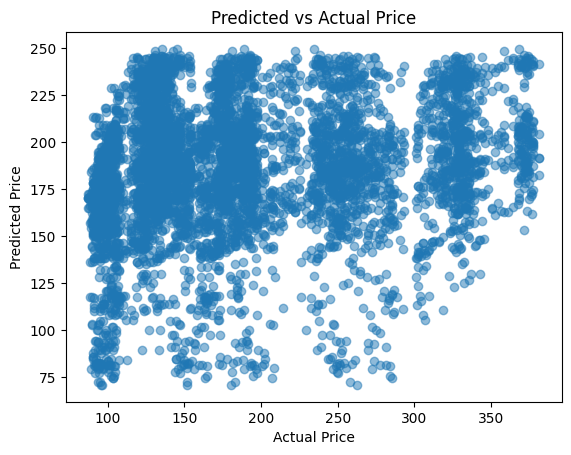

In [108]:
# Visualize relationship between actual and predicted values to assess regression performance
plt.scatter(y_test_reg, y_pred_reg, alpha=0.5)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual Price")
plt.show()

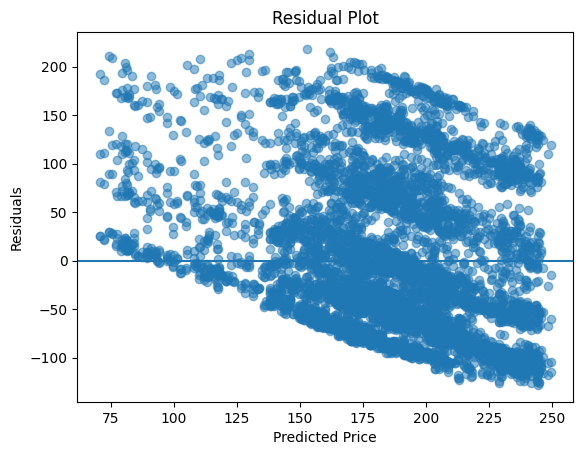

In [109]:
# Plot residuals to evaluate prediction errors and check for patterns in model performance
residuals = y_test_reg - y_pred_reg

plt.scatter(y_pred_reg, residuals, alpha=0.5)
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.axhline(0)
plt.show()

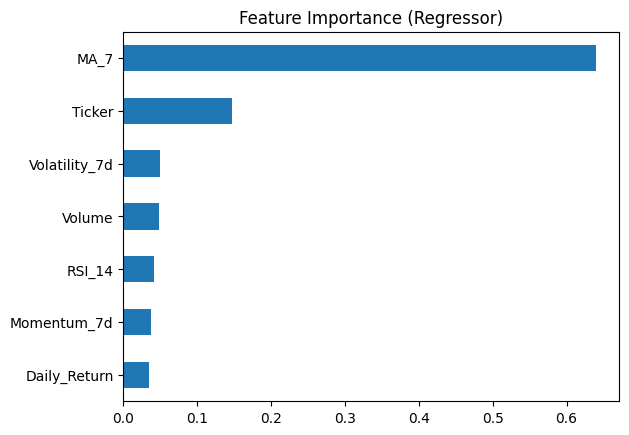

In [110]:
# Plot feature importance to identify which features contribute most to the regression model
import pandas as pd

importances = pd.Series(reg.feature_importances_, index=feature_cols)
importances.sort_values().plot(kind="barh")

plt.title("Feature Importance (Regressor)")
plt.show()

In [111]:
# Verify dataset split and class distribution to ensure no imbalance or data issues
print("Train size:", len(X_train))
print("Test size:", len(X_test))

print("\nDirection distribution (test):")
print(y_test_clf.value_counts())

Train size: 24560
Test size: 6140

Direction distribution (test):
Direction
1    3380
0    2760
Name: count, dtype: int64


In [112]:
# Combine regression and classification outputs into a single result set for interpretation
results = pd.DataFrame({
    "Actual Price": y_test_reg,
    "Predicted Price": y_pred_reg,
    "Direction": y_pred_clf
})

results["Direction_Label"] = results["Direction"].map({1: "Up", 0: "Down"})

results.head()

for i in range(10):
    print(f"{results['Direction_Label'].iloc[i]} | Predicted Price: {results['Predicted Price'].iloc[i]:.2f}")

Up | Predicted Price: 172.33
Up | Predicted Price: 172.33
Up | Predicted Price: 172.33
Down | Predicted Price: 168.82
Down | Predicted Price: 168.82
Down | Predicted Price: 168.82
Down | Predicted Price: 168.82
Down | Predicted Price: 168.82
Up | Predicted Price: 161.12
Up | Predicted Price: 161.12
